In [ ]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import pickle

In [ ]:
# Download latest version
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

csv_file = os.path.join(path,"Reviews.csv")
df = pd.read_csv(csv_file)

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.


In [ ]:
df.head(2)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...


In [ ]:
df.shape

(568454, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [ ]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


In [ ]:
df_clean = df[['Text','Score']]
df_clean.head(2)

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1


In [ ]:
df_clean.isnull().sum()

,0
Text,0
Score,0


In [ ]:
df['Text'][29]

"I don't know if it's the cactus or the tequila or just the unique combination of ingredients, but the flavour of this hot sauce makes it one of a kind!  We picked up a bottle once on a trip we were on and brought it back home with us and were totally blown away!  When we realized that we simply couldn't find it anywhere in our city we were bummed.<br /><br />Now, because of the magic of the internet, we have a case of the sauce and are ecstatic because of it.<br /><br />If you love hot sauce..I mean really love hot sauce, but don't want a sauce that tastelessly burns your throat, grab a bottle of Tequila Picante Gourmet de Inclan.  Just realize that once you taste it, you will never want to use any other sauce.<br /><br />Thank you for the personal, incredible service!"

In [ ]:
df_clean.head(2)

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1


In [ ]:
#Rating dist
score_counts = df_clean['Score'].value_counts().sort_index()
for score, count in score_counts.items():
  perc = (count/len(df_clean))*100
  print(f"{score} stars : {perc:.2f}%")

#biased more data -> good reviews

1 stars : 9.19%
2 stars : 5.24%
3 stars : 7.50%
4 stars : 14.19%
5 stars : 63.88%


In [ ]:
df_clean['Score'].value_counts()

,count
Score,
5,363122
4,80655
1,52268
3,42640
2,29769


In [ ]:
for score in [1,2,3,4,5]:
  sample_rev = df_clean[df_clean['Score'] == score]['Text'].iloc[0]
  print(f"\n🌟 {score}-STAR REVIEW:")
  print(f"{sample_rev}")


🌟 1-STAR REVIEW:
Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".

🌟 2-STAR REVIEW:
If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda.  The flavor is very medicinal.

🌟 3-STAR REVIEW:
This seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and doesn't have quite as much flavor either.  It didn't pass muster with my kids, so I probably won't buy it again.

🌟 4-STAR REVIEW:
This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly recomme

In [ ]:
#remove all 3 star - confusion

# deep copy and shallow copy

In [ ]:
df_binary = df_clean[df_clean['Score'] !=3].copy()
df_binary['sentiment'] = (df_binary['Score']>=4).astype(int)

In [ ]:
df_binary.head(2)

,Text,Score,sentiment
0,I have bought several of the Vitality canned d...,5,1
1,Product arrived labeled as Jumbo Salted Peanut...,1,0


In [ ]:
df_binary['Score'].value_counts()

,count
Score,
5,363122
4,80655
1,52268
2,29769


In [ ]:
#binary classification setup

In [ ]:
print(f"ORIGINAL DATA: {len(df_clean):,} reviews")
#after removing 3 star reviews
print(f"AFTER 3-STAR REMOVAL : {len(df_binary):,} reviews")
#class dis
print(f"Negative (1-2) star : {sum(df_binary['sentiment']==0):,}")
print(f"Positive (4-5) star : {sum(df_binary['sentiment']==1):,}")

ORIGINAL DATA: 568,454 reviews
AFTER 3-STAR REMOVAL : 525,814 reviews
Negative (1-2) star : 82,037
Positive (4-5) star : 443,777


In [ ]:
#handle class imbalnce
from sklearn.utils import resample

negative_reviews = df_binary[df_binary['sentiment']==0]
positive_reviews = df_binary[df_binary['sentiment']==1]

n_minority = len(negative_reviews)

positive_downsampled = resample(positive_reviews,
                                replace=False,
                                n_samples=n_minority)

In [ ]:
df_balanced = pd.concat([negative_reviews, positive_downsampled])
df_balanced.head(10)

,Text,Score,sentiment
1,Product arrived labeled as Jumbo Salted Peanut...,1,0
3,If you are looking for the secret ingredient i...,2,0
12,My cats have been happily eating Felidae Plati...,1,0
16,I love eating them and they are good for watch...,2,0
26,"The candy is just red , No flavor . Just plan...",1,0
50,"This oatmeal is not good. Its mushy, soft, I d...",1,0
62,Arrived in 6 days and were so stale i could no...,1,0
67,"I purchased the Mango flavor, and to me it doe...",2,0
73,Buyer Beware Please! This sweetener is not for...,1,0
74,It is okay. I would not go out of my way to b...,2,0


In [ ]:
df_balanced = df_balanced.sample(frac=1).reset_index(drop=True)

In [ ]:
df_balanced.head(10)

,Text,Score,sentiment
0,"I have a picky eater, diabetic dog. She has t...",5,1
1,"Crisp and tasty. Plus, they are well packed a...",5,1
2,It might have Taco Bell on the label but it is...,4,1
3,We've been drinking this tea for about 2 years...,5,1
4,"*Note: This may seem like a shill review, but ...",5,1
5,I agree with the other reviewer (regarding the...,1,0
6,I absolutely love these cookies. I bought them...,4,1
7,As a label reader I am impressed by the short ...,5,1
8,I am a professional dog trainer and I buy this...,5,1
9,I bought this set for my 3-year old. The set l...,2,0


In [ ]:
#after balancing
print(f"Negative : {sum(df_balanced['sentiment']==0):,}")
print(f"Positive : {sum(df_balanced['sentiment']==1):,}")

Negative : 82,037
Positive : 82,037


In [ ]:
#much smaller sample
sample_size = 50000
df_sample = df_balanced.sample(n=sample_size)
sample_neg = sum(df_sample['sentiment']==0)
sample_pos = sum(df_sample['sentiment']==1)

In [ ]:
print(f"-ve : {sample_neg:,}")
print(f"+ve : {sample_pos:,}")

-ve : 24,957
+ve : 25,043


In [ ]:
import re

In [ ]:
df_sample['Text'].iloc[3]

'I guess I was also disappointed in the assortment.  The info suggests you get 34 different coffees, so that you don\'t have to "buy 34 different boxes."  But as others reported, I got repeats in the assortment, as many as 4 of the exact same product.  Furthermore, I received two CIDER products, which are not coffee.  I don\'t want cider, I want coffee.  And thanks for the iced coffee sample, which I also don\'t drink.  Lastly, the k-cups are packaged in a brown paper bag which is stapled shut.  I\'m guessing that doesn\'t even meet food packaging codes; there\'s no product info, ingredient info or nutrition info.'

In [ ]:
def clean_text(text):
  text = text.lower()
  text = re.sub(r'<[^>]+>',' ',text)
  text = re.sub(r'^a-zA-Z\s','',text)
  text = " ".join(text.split())
  return text

In [ ]:
df_sample['clean_text'] = df_sample['Text'].apply(clean_text)

In [ ]:
df_sample.head(2)

,Text,Score,sentiment,clean_text
70384,"this tea is wonderful! smooth, deep, dark, ric...",5,1,"this tea is wonderful! smooth, deep, dark, ric..."
57768,this milk when first made was good but i tryed...,1,0,this milk when first made was good but i tryed...


In [ ]:
df_sample['clean_text'].iloc[3]

'i guess i was also disappointed in the assortment. the info suggests you get 34 different coffees, so that you don\'t have to "buy 34 different boxes." but as others reported, i got repeats in the assortment, as many as 4 of the exact same product. furthermore, i received two cider products, which are not coffee. i don\'t want cider, i want coffee. and thanks for the iced coffee sample, which i also don\'t drink. lastly, the k-cups are packaged in a brown paper bag which is stapled shut. i\'m guessing that doesn\'t even meet food packaging codes; there\'s no product info, ingredient info or nutrition info.'

In [ ]:
df_sample['Text'].iloc[3]

'I guess I was also disappointed in the assortment.  The info suggests you get 34 different coffees, so that you don\'t have to "buy 34 different boxes."  But as others reported, I got repeats in the assortment, as many as 4 of the exact same product.  Furthermore, I received two CIDER products, which are not coffee.  I don\'t want cider, I want coffee.  And thanks for the iced coffee sample, which I also don\'t drink.  Lastly, the k-cups are packaged in a brown paper bag which is stapled shut.  I\'m guessing that doesn\'t even meet food packaging codes; there\'s no product info, ingredient info or nutrition info.'

In [ ]:
MAX_FEATURES = 10000 # vocabulary
MAX_LEN = 100 # lngth   compute cost

In [ ]:
X = df_sample['clean_text'].values #feature
y = df_sample['sentiment'].values  #target

In [ ]:
tokenizer = Tokenizer(num_words=MAX_FEATURES, oov_token = '<OOV>')
tokenizer.fit_on_texts(X)

In [ ]:
#convert sent in to sequences
X_sequences = tokenizer.texts_to_sequences(X)

In [ ]:
print(X_sequences[0],end=',')
print('\n')
print(X_sequences[1],end=',')

[9, 55, 10, 344, 508, 1453, 339, 528, 55, 7, 840, 47, 470, 3, 78, 15, 195, 5, 4519, 1180, 17, 64, 2, 470],

[9, 210, 46, 94, 111, 16, 36, 17, 3, 7831, 1037, 5, 1, 8, 7, 11, 2, 1486, 4, 713, 329, 547, 7, 9939, 3, 752, 4876, 3, 43, 15, 4021, 95, 33, 6, 79, 9, 32, 7, 7832, 54, 836],

In [ ]:
X_padded = pad_sequences(X_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

In [ ]:
print(X_padded[0],end=',')
print('\n')
print(X_padded[1],end=',')

[   9   55   10  344  508 1453  339  528   55    7  840   47  470    3
   78   15  195    5 4519 1180   17   64    2  470    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0],

[   9  210   46   94  111   16   36   17    3 7831 1037    5    1    8
    7   11    2 1486    4  713  329  547    7 9939    3  752 4876    3
   43   15 4021   95   33    6   79    9   32    7 7832   54  836    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0   

In [ ]:
X_train, X_test, y_train , y_test = train_test_split(
    X_padded, y,
    test_size=0.20,
    stratify=y
)

In [ ]:
## RNN model - NN

In [ ]:
def create_rnn_model():
  model = Sequential([
      Embedding(input_dim=MAX_FEATURES, output_dim=128, input_length=MAX_LEN),
      SimpleRNN(units=64, return_sequences=False),
      Dropout(0.50),
      Dense(32, activation='relu'),
      Dense(1, activation='sigmoid')
  ])
  return model

In [ ]:
rnn_model = create_rnn_model()

#compile the nn
rnn_model.compile(
    optimizer='adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
rnn_history = rnn_model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=5, #30? # epochs lesser -> 234,5 -> 150.   ->
    validation_split=0.20,
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - accuracy: 0.5194 - loss: 0.6927 - val_accuracy: 0.5385 - val_loss: 0.6887
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5255 - loss: 0.6895 - val_accuracy: 0.4904 - val_loss: 0.6937
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.5021 - loss: 0.6937 - val_accuracy: 0.4888 - val_loss: 0.6931
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.5036 - loss: 0.6935 - val_accuracy: 0.5190 - val_loss: 0.6931
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.5027 - loss: 0.6933 - val_accuracy: 0.4904 - val_loss: 0.6931


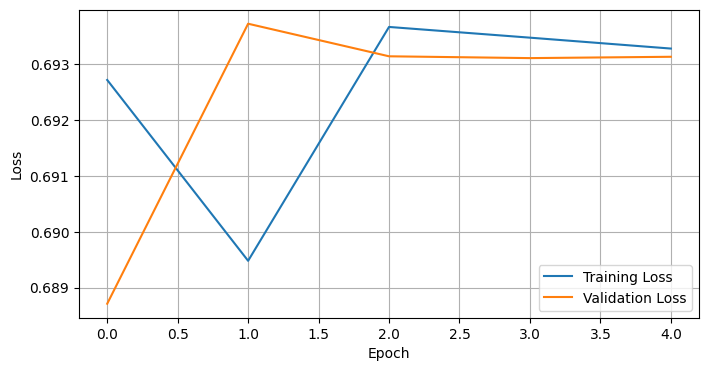

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(rnn_history.history['loss'],label='Training Loss')
plt.plot(rnn_history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

In [ ]:
def create_lstm_model():
  model = Sequential([
      Embedding(input_dim=MAX_FEATURES, output_dim=128, input_length=MAX_LEN),
      LSTM(units=64, return_sequences=False),
      Dropout(0.50),
      Dense(32, activation='relu'),
      Dense(1, activation='sigmoid')
  ])
  return model

lstm_model = create_lstm_model()

#compile the nn
lstm_model.compile(
    optimizer='adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [ ]:
lstm_history = lstm_model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=5, #30? # epochs lesser -> 234,5 -> 150.   ->
    validation_split=0.20,
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.5350 - loss: 0.6874 - val_accuracy: 0.5650 - val_loss: 0.6717
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.6318 - loss: 0.6320 - val_accuracy: 0.6530 - val_loss: 0.6109
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.6795 - loss: 0.6169 - val_accuracy: 0.4990 - val_loss: 0.6865
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.5710 - loss: 0.6543 - val_accuracy: 0.6058 - val_loss: 0.6336
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.7697 - loss: 0.5222 - val_accuracy: 0.7818 - val_loss: 0.5145


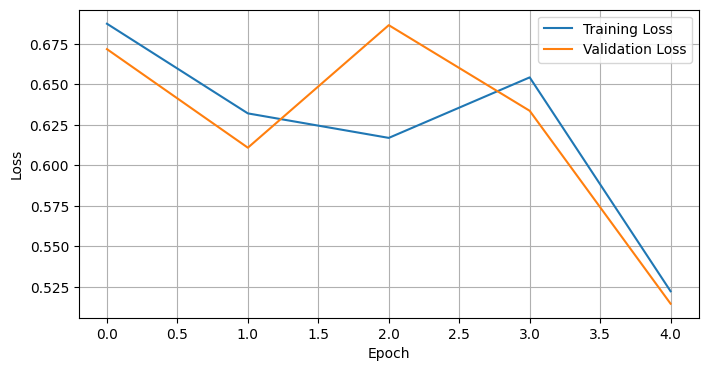

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(lstm_history.history['loss'],label='Training Loss')
plt.plot(lstm_history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

In [ ]:
#next step -> increase epoch, tune parameter, callbacks - early , model check ,

In [ ]:
param_grid = {
    'model_type':['rnn','lstm'],
    "embedding_dim":[32,16,64,128],
    "units":[16,32,64,128,256],
    "dropout_rate":[0.3,0.1,0.5],
    "learning_rate":[0.0001, 0.001, 0.01]
}

#bo time -> exact

In [ ]:
def create_model_with_params(model_type='lstm',embedding_dim=128,
                             units=64,dropout_rate=0.5, learning_rate=0.001):
  model = Sequential([
      Embedding(MAX_FEATURES, embedding_dim, input_length=MAX_LEN)
  ])

  if model_type == 'lstm':
    model.add(LSTM(units, return_sequences=False))
  else:
    model.add(SimpleRNN(units,return_sequences=False))

  model.add(Dropout(dropout_rate))
  model.add(Dense(32,activation='relu'))
  model.add(Dense(1,activation='sigmoid'))

  model.compile(
      optimizer=Adam(learning_rate=learning_rate),
      loss='binary_crossentropy',
      metrics = ['accuracy']
  )
  return model


In [ ]:
def random_search(n_trials=8):
  results=[]
  np.random.seed(10)
  for i in range(n_trials):
    params = {
        'model_type':str(np.random.choice(param_grid['model_type'])),
        'embedding_dim': int(np.random.choice(param_grid['embedding_dim'])),
        'units': int(np.random.choice(param_grid['units'])),
        'dropout_rate': float(np.random.choice(param_grid['dropout_rate'])),
        'learning_rate': float(np.random.choice(param_grid['learning_rate'])),
    }
    print(f"\n--- Trial {i+1}/{n_trials} ---")

    try:
      model = create_model_with_params(**params)
      history = model.fit(
          X_train, y_train,
          batch_size=128,
          epochs=3,
          validation_split=0.2
      )

      val_accuracy = max(history.history['val_accuracy'])

      results.append({
          'trial':i+1,
          'params':params,
          'val_accuracy' : val_accuracy,
          'model':model
      })

      print(f"Validation Accuracy : {val_accuracy:.2f}")
    except Exception as e:
      print(f"Error : {str(e)}")
  return results

In [ ]:
search_results = random_search(8)


--- Trial 1/8 ---
Epoch 1/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.5293 - loss: 0.6958 - val_accuracy: 0.5471 - val_loss: 0.6907
Epoch 2/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.5415 - loss: 0.6919 - val_accuracy: 0.5321 - val_loss: 0.6893
Epoch 3/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.6500 - loss: 0.6265 - val_accuracy: 0.5591 - val_loss: 0.6837
Validation Accuracy : 0.56

--- Trial 2/8 ---
Epoch 1/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.5247 - loss: 0.6925 - val_accuracy: 0.5318 - val_loss: 0.6915
Epoch 2/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5340 - loss: 0.6887 - val_accuracy: 0.6571 - val_loss: 0.6307
Epoch 3/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8102 - loss: 0.4530 - val_accuracy: 0.8371 - val_loss: 0.3818
Validation Accuracy : 0.84

--- Trial 3/8 ---
Epoch 1/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.7222 - loss: 0.5154 - val_accuracy: 0.8455 - val_los

In [ ]:
best_result = max(search_results, key=lambda x: x['val_accuracy'])
best_result

{'trial': 8,
 'params': {'model_type': 'lstm',
  'embedding_dim': 16,
  'units': 128,
  'dropout_rate': 0.1,
  'learning_rate': 0.01},
 'val_accuracy': 0.8893749713897705,
 'model': <Sequential name=sequential_9, built=True>}

In [ ]:
if search_results:
  best_params = best_result['params']

  best_model = create_model_with_params(**best_params)

  callbacks = [
      ModelCheckpoint(
          'best_amazon_sentiment_model.h5',
          monitor = 'val_accuracy',
          save_best_only=True,
          mode='max',
      ),

      EarlyStopping(
          monitor='val_loss',
          patience=3,
          restore_best_weights=True
      )
  ]

  print("Final model training.....\n")
  final_history = best_model.fit(
      X_train, y_train,
      batch_size=128,
      epochs=10,
      validation_split = 0.20,
      callbacks=callbacks,
  )

  with open('amazon_sentiment_tokenizer.pkl',"wb") as f:
    pickle.dump(tokenizer, f)

else:
  print(f"Cannot train model - issues")

Final model training.....

Epoch 1/10
248/250 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5172 - loss: 0.6928

250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5497 - loss: 0.6786 - val_accuracy: 0.7894 - val_loss: 0.4803
Epoch 2/10
245/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8428 - loss: 0.3720

250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8634 - loss: 0.3308 - val_accuracy: 0.8891 - val_loss: 0.2785
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9252 - loss: 0.1997

250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9227 - loss: 0.2071 - val_accuracy: 0.8954 - val_loss: 0.2637
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9473 - loss: 0.1488 - val_accuracy: 0.8924 - val_loss: 0.2827
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9634 - loss: 0.1107 - val_accuracy: 0.8935 - val_loss: 0.3214
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.9742 - loss: 0.0795 - val_accuracy: 0.8888 - val_loss: 0.3650


In [ ]:
#model training -> best hype

loaded_model = load_model('best_amazon_sentiment_model.h5')
with open('amazon_sentiment_tokenizer.pkl','rb') as f:
  loaded_tokenizer = pickle.load(f)

print("Model loaded successfully!!!")

Model loaded successfully!!!


In [ ]:
y_pred_prob = loaded_model.predict(X_test)
y_pred = (y_pred_prob > 0.50).astype(int).flatten()

test_accuracy = accuracy_score(y_test, y_pred)
print(f"test_accuracy : {test_accuracy:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
test_accuracy : 0.89


In [ ]:
test_sentences = ['this product is really good, i am a big fan of this',
                  "terrible quality, waste of my money",
                  "great food, amazing quality can do better but for now i am happy"]

def predict_sentiment(text):
  clean = clean_text(text)
  sequence = loaded_tokenizer.texts_to_sequences([clean])
  padded = pad_sequences(sequence, maxlen=MAX_LEN, padding='post')
  prob = loaded_model.predict(padded)[0][0]
  sentiment = "Positive" if prob >0.50 else "Negative"
  return sentiment, prob

In [ ]:
predict_sentiment(test_sentences[2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


('Positive', np.float32(0.99477863))